# **Benchmarking Malayalam Automatic Speech Recognition Models: AI4Bharat Indic Conformer versus Whisper Small (IMaSC)**

# Step 1: Workspace Setup
Run this cell to create the folder for your audio files and a template for your transcriptions. Upload your audio files to `audio_files/` and update `transcriptions.csv` with the correct text.

In [ ]:
import os

# 1. Create directory for audio files
if not os.path.exists('audio_files'):
    os.makedirs('audio_files')
    print("Created 'audio_files/' directory.")

# 2. Create a clean template CSV file
# We use newline='' and a standard string to ensure the CSV structure is valid
csv_path = 'transcriptions.csv'
if not os.path.exists(csv_path):
    with open(csv_path, 'w', encoding='utf-8') as f:
        f.write('id,transcription\n')
        f.write('mlf_09852_02133997265,മാതൃക വാചകം\n')
    print(f"Created {csv_path} template.")
else:
    print(f"{csv_path} already exists. Please ensure it has 'id' and 'transcription' columns.")

transcriptions.csv already exists. Please ensure it has 'id' and 'transcription' columns.


In [ ]:
import os
import glob
import pandas as pd

# Automatically update your CSV template with all found audio IDs
audio_dir = '/content/drive/MyDrive/audio_files'
audio_ids = [os.path.basename(f).replace('.wav', '') for f in glob.glob(os.path.join(audio_dir, '*.wav'))]

if audio_ids:
    new_df = pd.DataFrame({'id': audio_ids, 'transcription': ['ADD_TEXT_HERE'] * len(audio_ids)})
    new_df.to_csv('transcriptions_template.csv', index=False, encoding='utf-8')
    print(f"Updated template created: 'transcriptions_template.csv' with {len(audio_ids)} files.")
    print("Download this file, fill in the actual text, and re-upload it as 'transcriptions.csv'.")
else:
    print("No audio files found in Google Drive yet. Check your path.")

# Malayalam ASR Evaluation: AI4Bharat vs Whisper Small (IMaSC)
This notebook evaluates the performance of the AI4Bharat Conformer and Whisper Small (fine-tuned on IMaSC) models on Malayalam audio using Word Error Rate (WER) and Character Error Rate (CER) metrics.

### Resource Links
- **Datasets**: [OpenSLR Malayalam (SLR63)](https://www.openslr.org/63/)
- **AI4Bharat Models**: [Hugging Face - AI4Bharat](https://huggingface.co/ai4bharat)
- **OpenSLR Based Models**: [Hugging Face Search (Malayalam ASR)](https://huggingface.co/models?pipeline_tag=automatic-speech-recognition&language=ml)

In [ ]:
!pip install -q transformers torch torchaudio librosa jiwer huggingface_hub onnxruntime tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import torch
import torchaudio
import pandas as pd
import glob
from jiwer import wer, cer
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

def calculate_metrics(reference, hypothesis):
    if not reference or not hypothesis:
        return 1.0, 1.0
    # Normalize both for a fair comparison using the globally defined normalize_malayalam
    reference = normalize_malayalam(reference)
    hypothesis = normalize_malayalam(hypothesis)
    if not reference or not hypothesis:
        return 1.0, 1.0
    return wer(reference, hypothesis), cer(reference, hypothesis)

def transcribe_audio(audio_path, model_obj, model_type="whisper"):
    wav, sr = torchaudio.load(audio_path)
    if sr != 16000:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=16000)
        wav = resampler(wav)

    if model_type == "ai4bharat":
        wav_tensor = torch.mean(wav, dim=0).unsqueeze(0).to(device)
        with torch.no_grad():
            transcription = model_obj(wav_tensor, "ml", "ctc")
        return transcription[0] if isinstance(transcription, list) else transcription
    elif model_type == "whisper":
        result = model_obj(audio_path)
        return result["text"]

Using device: cuda


### OpenSLR / Generic Hugging Face Models
Many OpenSLR models are released as fine-tuned versions of `facebook/wav2vec2-large-xlsr-53` on Hugging Face.

### Evaluation Loop
Assuming you have a folder `audio_files/` where filenames are IDs, and a `transcriptions.csv` mapping IDs to Malayalam text.

### Load Open-Source Models
We will initialize the AI4Bharat model and an OpenSLR-based fine-tuned XLS-R model.

### Hugging Face Authentication
Since the AI4Bharat Conformer model is gated, you must:
1. Accept the terms on the [model page](https://huggingface.co/ai4bharat/indic-conformer-600m-multilingual).
2. Run the cell below and enter your Hugging Face Access Token.

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
from transformers import AutoModel, AutoProcessor, pipeline
import torch

def load_models():
    # 1. AI4Bharat Indic Conformer
    ai4_id = "ai4bharat/indic-conformer-600m-multilingual"
    # 2. Whisper Malayalam Model (Switched to Small-IMaSC version)
    whisper_id = "thennal/whisper-small-ml-imasc"

    print(f"Loading {ai4_id} onto {device}...")
    ai4_model = AutoModel.from_pretrained(ai4_id, trust_remote_code=True).to(device)
    ai4_model.eval()

    print(f"Loading {whisper_id} onto {device}...")
    # Set device=0 for the first GPU
    whisper_pipe = pipeline(
        "automatic-speech-recognition",
        model=whisper_id,
        device=0 if torch.cuda.is_available() else -1
    )

    return ai4_model, whisper_pipe

try:
    ai4_model, whisper_pipe = load_models()
    print("\nModels loaded successfully on GPU!")
except Exception as e:
    print(f"\nError loading models: {e}")

Loading ai4bharat/indic-conformer-600m-multilingual onto cuda...


config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

model_onnx.py:   0%|          | 0.00/9.64k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/ai4bharat/indic-conformer-600m-multilingual:
- model_onnx.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


Please check FRAME_DURATION_MS. The timestamps can be inaccurate
Please check FRAME_DURATION_MS. The timestamps can be inaccurate


...

normalizer.json:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.11k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.06k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]


Models loaded successfully on GPU!


### Complete Evaluation Pipeline
Upload your transcriptions as a CSV with columns `id` and `transcription`. Audio files should be in a folder named `audio_files/`.

In [ ]:
import os
import glob
import pandas as pd
from tqdm.auto import tqdm

# Updated path to pull audio from Google Drive
AUDIO_PATH = "/content/drive/MyDrive/audio_files"
audio_files = sorted(glob.glob(os.path.join(AUDIO_PATH, "*.wav")))

def run_comparison(file_list, trans_map):
    results = []
    for audio_path in tqdm(file_list, desc="Evaluating Accuracy"):
        audio_id = os.path.basename(audio_path).replace('.wav', '')
        reference_text = trans_map.get(audio_id, None)

        # AI4Bharat Inference
        try:
            hyp_ai4 = transcribe_audio(audio_path, ai4_model, model_type="ai4bharat")
            w_ai4, c_ai4 = calculate_metrics(reference_text, hyp_ai4) if reference_text else ("N/A", "N/A")
        except Exception as e:
            hyp_ai4, w_ai4, c_ai4 = f"Error: {str(e)}", "N/A", "N/A"

        # Whisper Inference
        try:
            hyp_whisper = transcribe_audio(audio_path, whisper_pipe, model_type="whisper")
            w_whisper, c_whisper = calculate_metrics(reference_text, hyp_whisper) if reference_text else ("N/A", "N/A")
        except Exception as e:
            hyp_whisper, w_whisper, c_whisper = f"Error: {str(e)}", "N/A", "N/A"

        results.append({
            "File ID": audio_id,
            "Reference": reference_text if reference_text else "MISSING",
            "AI4Bharat": hyp_ai4,
            "AI4B_WER": w_ai4,
            "AI4B_CER": c_ai4,
            "Whisper": hyp_whisper,
            "Whisper_WER": w_whisper,
            "Whisper_CER": c_whisper
        })
    return pd.DataFrame(results)

try:
    # Search for transcription file in /content/ (local upload) or the Drive folder
    ref_found = False
    for possible_path in ['/content/transcription.tsv', '/content/transcriptions.csv', os.path.join(AUDIO_PATH, 'transcription.tsv')]:
        if os.path.exists(possible_path):
            sep = '\t' if possible_path.endswith('.tsv') else ','
            print(f"Loading references from {possible_path}...")
            ref_df = pd.read_csv(possible_path, sep=sep)
            ref_found = True
            break

    if not ref_found:
        raise FileNotFoundError("No reference file found. Please upload transcription.tsv to the Drive folder or Colab root.")

    ref_df.columns = [c.strip() for c in ref_df.columns]
    transcription_map = dict(zip(ref_df['id'].astype(str), ref_df['transcription'].astype(str)))

    if 'ai4_model' in globals() and 'whisper_pipe' in globals() and audio_files:
        df_comparison = run_comparison(audio_files, transcription_map)
        display(df_comparison.head())
    else:
        print(f"Found {len(audio_files)} files in {AUDIO_PATH}. Please check if models are loaded.")
except Exception as e:
    print(f"Error: {e}")

Loading references from /content/transcription.tsv...


Evaluating Accuracy:   0%|          | 0/2113 [00:00<?, ?it/s]

,File ID,Reference,AI4Bharat,AI4B_WER,AI4B_CER,Whisper,Whisper_WER,Whisper_CER
0,mlf_01130_00015565294,അങ്ങനെ രണ്ടാം ലോകമഹായുദ്ധം അവസാനിച്ചു,അങ്ങനെ രണ്ടാം ലോകമഹായുദ്ധം അവസാനിച്ചു,0.0,0.0,അങ്ങനെ രണ്ടാം ലോകമഹായുദ്ധം അവസാനിച്ചു,0.0,0.0
1,mlf_01130_00017668262,അതിന്റെ മറുഭാഗം മറ്റൊരു കുഴൽ വഴി വെന്റിലേറ്റർ ...,അതിന്റെ മറുഭാഗം മറ്റൊരു കുഴൽ വഴി വെന്റിലേറ്റർ ...,0.0,0.0,അതിന്റെ മറുഭാഗം മറ്റരു കുഴൽ വഴി വെന്റിലേറ്റർ യ...,0.375,0.054054
2,mlf_01130_00033664250,അവസാനം ചെ സാന്താ ക്ലാര ആക്രമിക്കാനായി തന്റെ ആത...,അവസാനം ചെ സാന്താക്ലാര ആക്രമിക്കാനായി തന്റെ ആത്...,0.222222,0.013699,അവസാനം ചെ സാന്താക്ലാരാക്രമിക്കാനായി തന്റെ ആത്മ...,0.666667,0.09589
3,mlf_01130_00038107106,ആരണ്യർക്ക് ശേഷം റേ സമകാലീന ബംഗാളി യാഥാർത്ഥ്യങ്...,ആരണ്യർക്കു ശേഷം റെേ സമകാലീന ബംഗാിയാഥാർത്ഥ്യങ്ങ...,0.714286,0.1,ആരണീർക്ക് ശേഷം റേ സമകാലീന ബംഗാളി യാതാർത്ഥങ്ങളി...,0.428571,0.128571
4,mlf_01130_00083214416,അതോടെ ഒക്ടേവിയന് ആ സ്ഥലങ്ങളുടെ നിയന്ത്രണാധികാര...,അതോടെ ഒക്ടേവിയന് ആ സ്ഥലങ്ങളുടെ നിയന്ത്രണാധികാര...,0.0,0.0,അതോടെ ഒക്ടേവിയന് ആ സ്ഥലങ്ങളുടെ നീതിർണാധികാരവം ...,0.166667,0.122807


## Comprehensive Performance Analysis
This section aggregates the results, performs linguistic normalization for Malayalam, and identifies specific patterns in model errors.

### Visualizing ASR Performance
This section generates plots to compare the accuracy (WER) of the two models across your dataset.

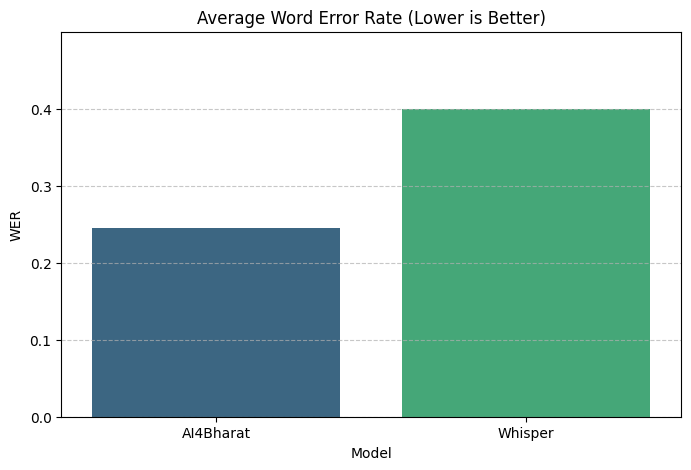

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data for plotting
plot_df = df_comparison.copy()
# Convert 'N/A' or errors to NaN for plotting
plot_df['AI4B_WER'] = pd.to_numeric(plot_df['AI4B_WER'], errors='coerce')
plot_df['Whisper_WER'] = pd.to_numeric(plot_df['Whisper_WER'], errors='coerce')

# 2. Global Average Comparison
avg_wer = pd.DataFrame({
    'Model': ['AI4Bharat', 'Whisper'],
    'Average WER': [plot_df['AI4B_WER'].mean(), plot_df['Whisper_WER'].mean()]
})

plt.figure(figsize=(8, 5))
# Updated to use hue and legend=False to avoid deprecation warning
sns.barplot(x='Model', y='Average WER', hue='Model', data=avg_wer, palette='viridis', legend=False)
plt.title('Average Word Error Rate (Lower is Better)')
plt.ylabel('WER')
plt.ylim(0, max(avg_wer['Average WER']) + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

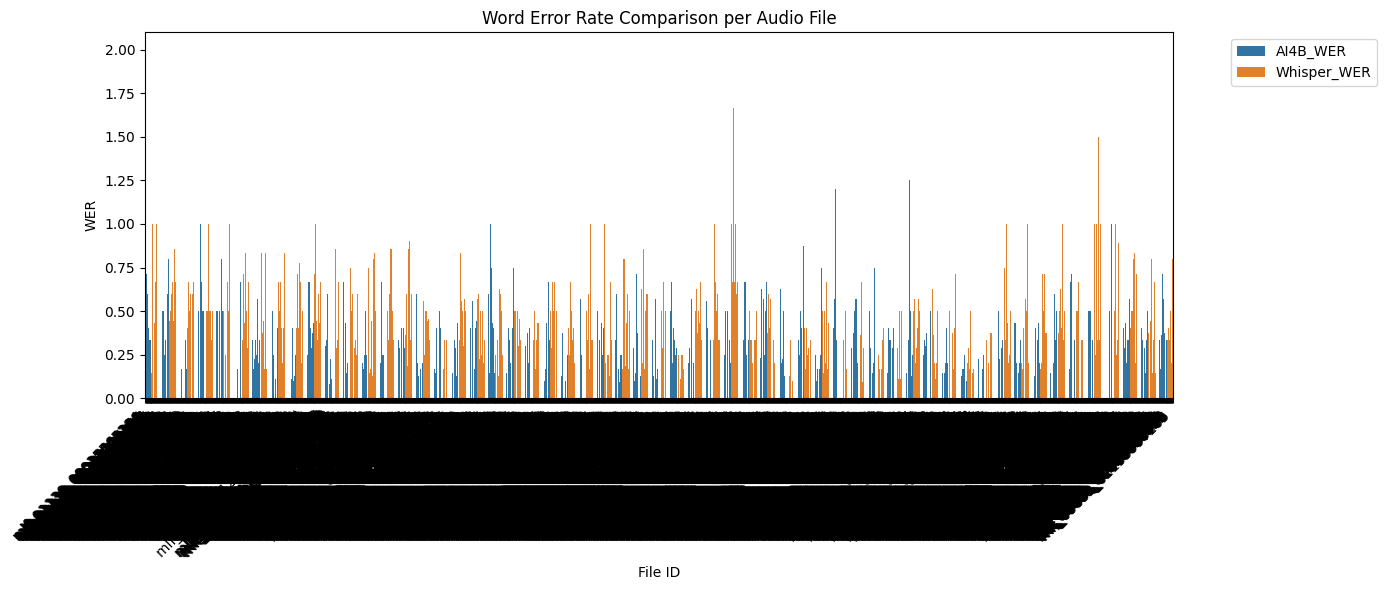

In [ ]:
# 3. Per-File Comparison (Bar Chart)
# Melt the dataframe for seaborn side-by-side comparison
comparison_melted = plot_df.melt(id_vars='File ID', value_vars=['AI4B_WER', 'Whisper_WER'],
                                var_name='Model', value_name='WER')

plt.figure(figsize=(14, 6))
sns.barplot(x='File ID', y='WER', hue='Model', data=comparison_melted)
plt.xticks(rotation=45, ha='right')
plt.title('Word Error Rate Comparison per Audio File')
plt.ylabel('WER')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Detailed Performance Summary
Beyond WER, we also look at Character Error Rate (CER) and aggregate stats to understand model reliability.

,Model,Avg WER,Avg CER
0,AI4Bharat,0.245219,0.040319
1,Whisper,0.399955,0.081430


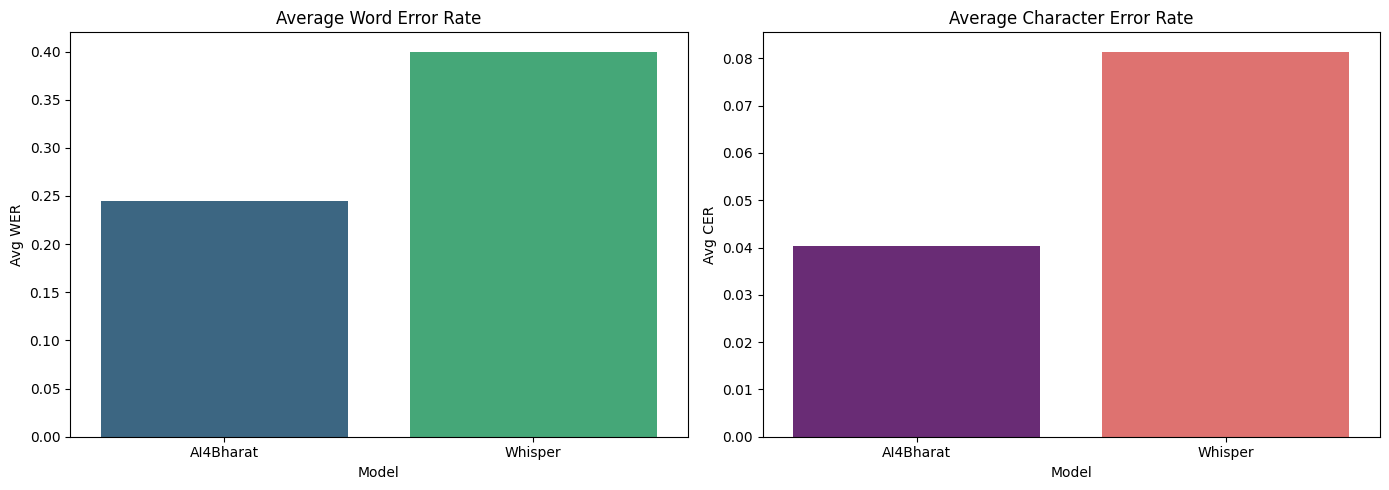

### Project Submission: Export Results
Run this cell to save your benchmarking data to a CSV file that you can download and submit with your project.

In [ ]:
# Save the detailed results to a CSV
output_filename = "asr_benchmark_results.csv"
df_comparison.to_csv(output_filename, index=False)
print(f"Successfully saved results to {output_filename}. You can download this from the folder icon on the left.")

Successfully saved results to asr_benchmark_results.csv. You can download this from the folder icon on the left.


### Exporting Visualizations
Run the cell below to save all generated charts as image files for your project documentation.

Saved: benchmark_plots/1_average_wer_summary.png


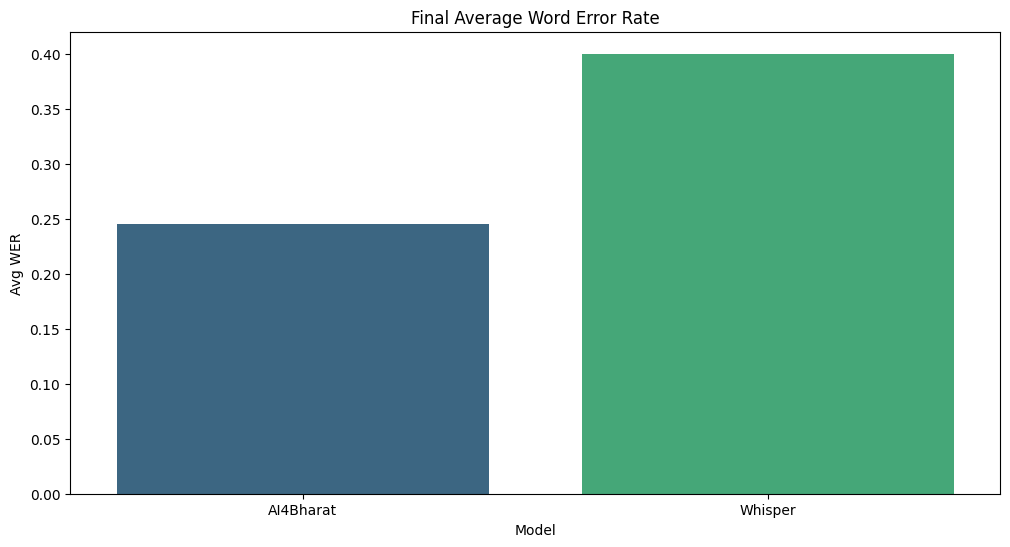

Saved: benchmark_plots/2_error_heatmap.png


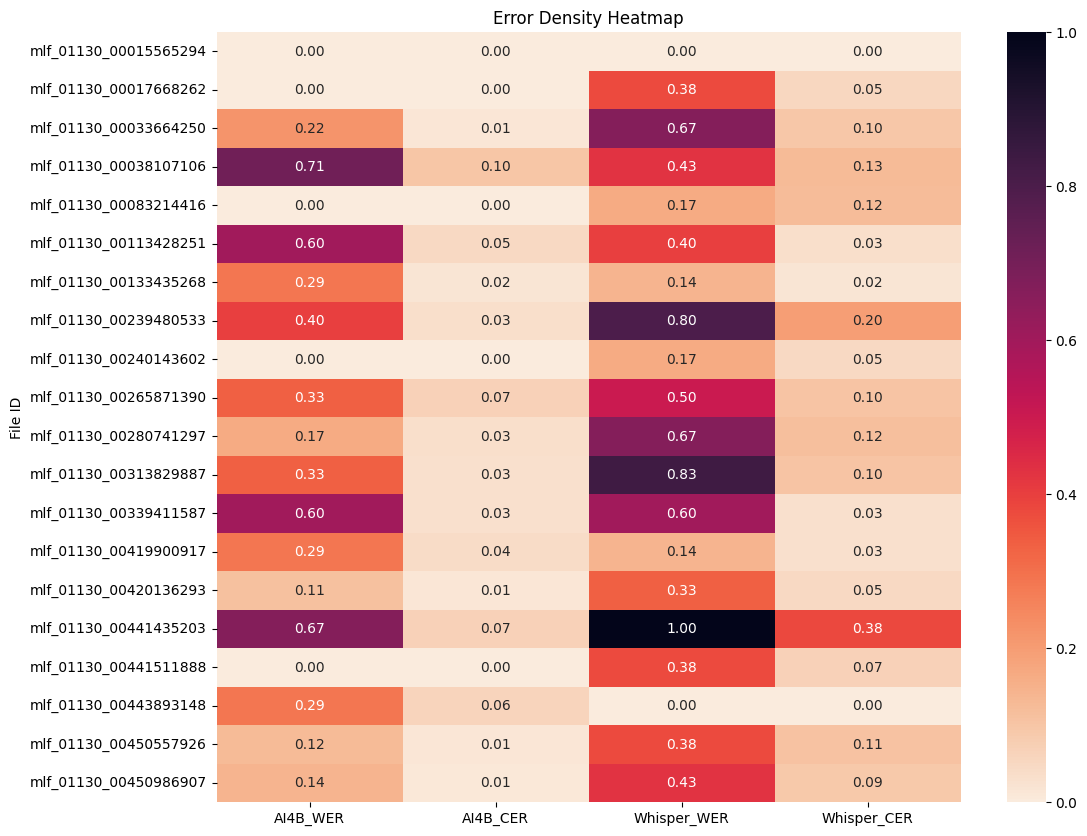

Saved: benchmark_plots/3_wer_cer_correlation.png


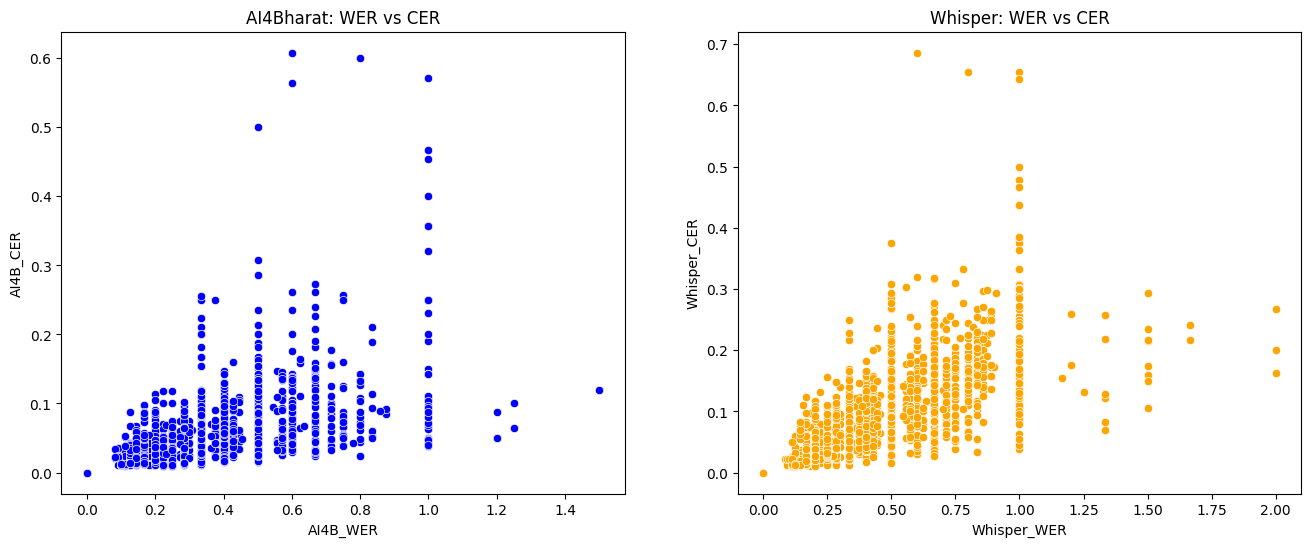


All benchmark images are ready for your project report!


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup Export Directory
image_export_dir = 'benchmark_plots'
if not os.path.exists(image_export_dir):
    os.makedirs(image_export_dir)

def save_plot(name):
    path = os.path.join(image_export_dir, f"{name}.png")
    plt.savefig(path, bbox_inches='tight', dpi=300)
    print(f"Saved: {path}")

# 2. Save Summary Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Avg WER', hue='Model', data=avg_metrics, palette='viridis', legend=False)
plt.title('Final Average Word Error Rate')
save_plot('1_average_wer_summary')
plt.show()

# 3. Save Heatmap (Top 20 Samples)
plt.figure(figsize=(12, 10))
subset_heat = df_comparison.head(20).copy().set_index('File ID')
heat_data = subset_heat[['AI4B_WER', 'AI4B_CER', 'Whisper_WER', 'Whisper_CER']].apply(pd.to_numeric, errors='coerce')
sns.heatmap(heat_data, annot=True, cmap='rocket_r', fmt='.2f')
plt.title('Error Density Heatmap')
save_plot('2_error_heatmap')
plt.show()

# 4. Save Correlation Scatter Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=plot_df, x='AI4B_WER', y='AI4B_CER', ax=ax1, color='blue')
ax1.set_title('AI4Bharat: WER vs CER')
sns.scatterplot(data=plot_df, x='Whisper_WER', y='Whisper_CER', ax=ax2, color='orange')
ax2.set_title('Whisper: WER vs CER')
save_plot('3_wer_cer_correlation')
plt.show()

print("\nAll benchmark images are ready for your project report!")

In [ ]:
import shutil
from google.colab import files

# Zip the folder containing all plots
shutil.make_archive('malayalam_asr_plots', 'zip', 'benchmark_plots')

print("Folder zipped successfully as 'malayalam_asr_plots.zip'.")
# Uncomment the line below if you want to trigger the download prompt immediately
# files.download('malayalam_asr_plots.zip')

Folder zipped successfully as 'malayalam_asr_plots.zip'.


### 1. Dataset Scale & Duration
Calculating the total duration of the processed audio to understand the benchmark's scale.

Total Audio Analysed: 2113 files
Total Duration: 182 minutes and 5 seconds


### 2. Linguistic Character Loss Analysis
Identifying which Malayalam characters are most frequently 'lost' (deleted) helps pinpoint phonetic weaknesses in the models.

Top 5 Characters Deleted by AI4Bharat:


,Character,Count
3,്,204
18,‍,188
0,,162
12,‌,137
16,.,131



Top 5 Characters Deleted by Whisper:


,Character,Count
2,്,318
3,,233
21,‌,133
30,.,132
4,ാ,127


### Combined Error Analysis (WER vs CER)
This visualization shows how Character Errors relate to Word Errors, providing a deeper look into model behavior.

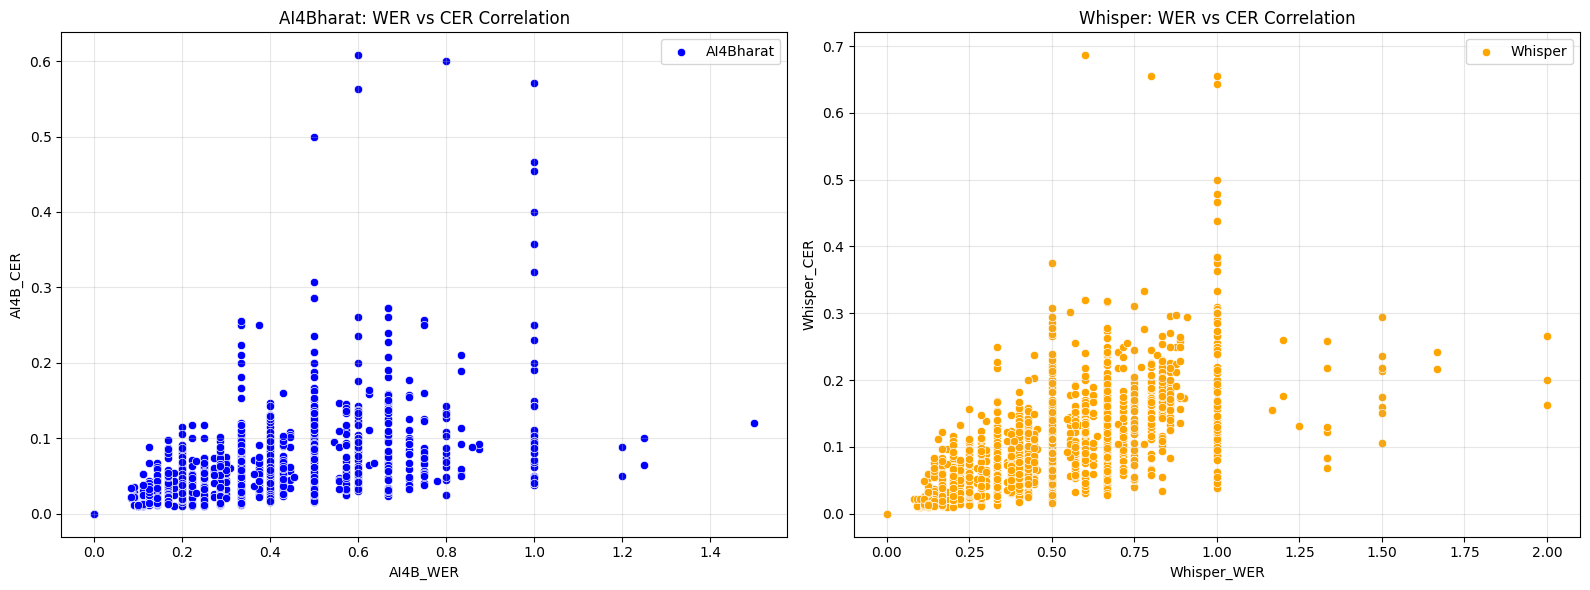

### Error Density Heatmapping
Heatmaps allow us to see the distribution of errors across the dataset. A 'hotter' (brighter) cell indicates a file where the model significantly struggled with both word and character accuracy.

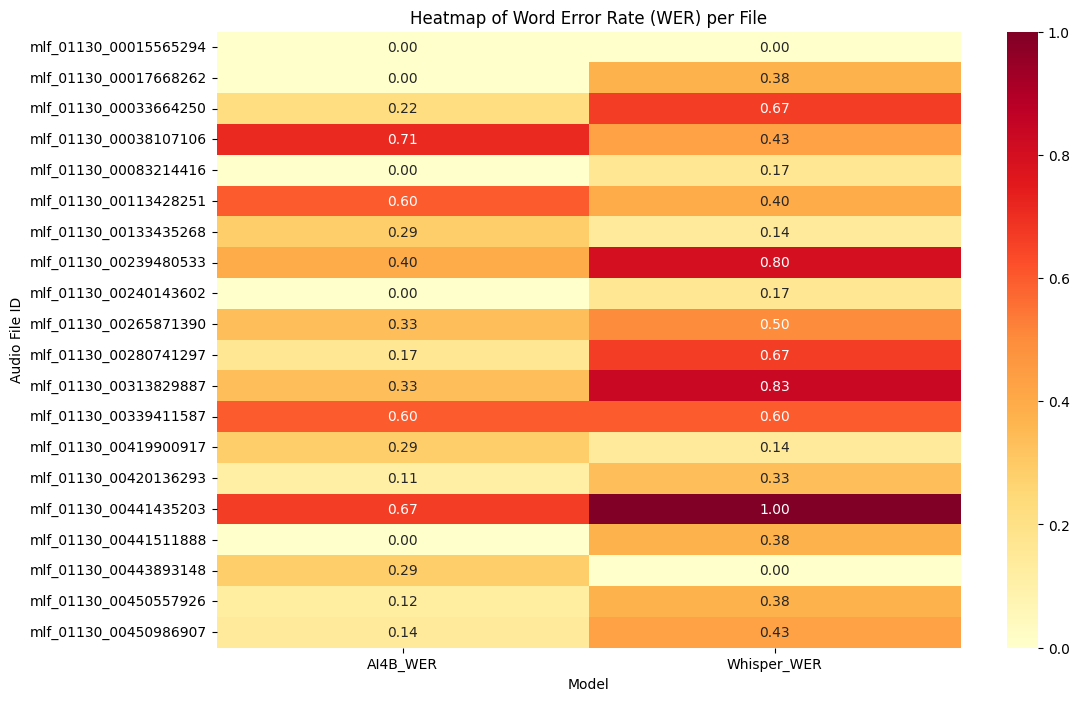

### Advanced Error Density Heatmapping
This heatmap visualizes the distribution of both Word Error Rate (WER) and Character Error Rate (CER) for the top 20 files. It helps identify if a model's failure is at the phonetic level (high CER) or linguistic level (high WER but low CER).

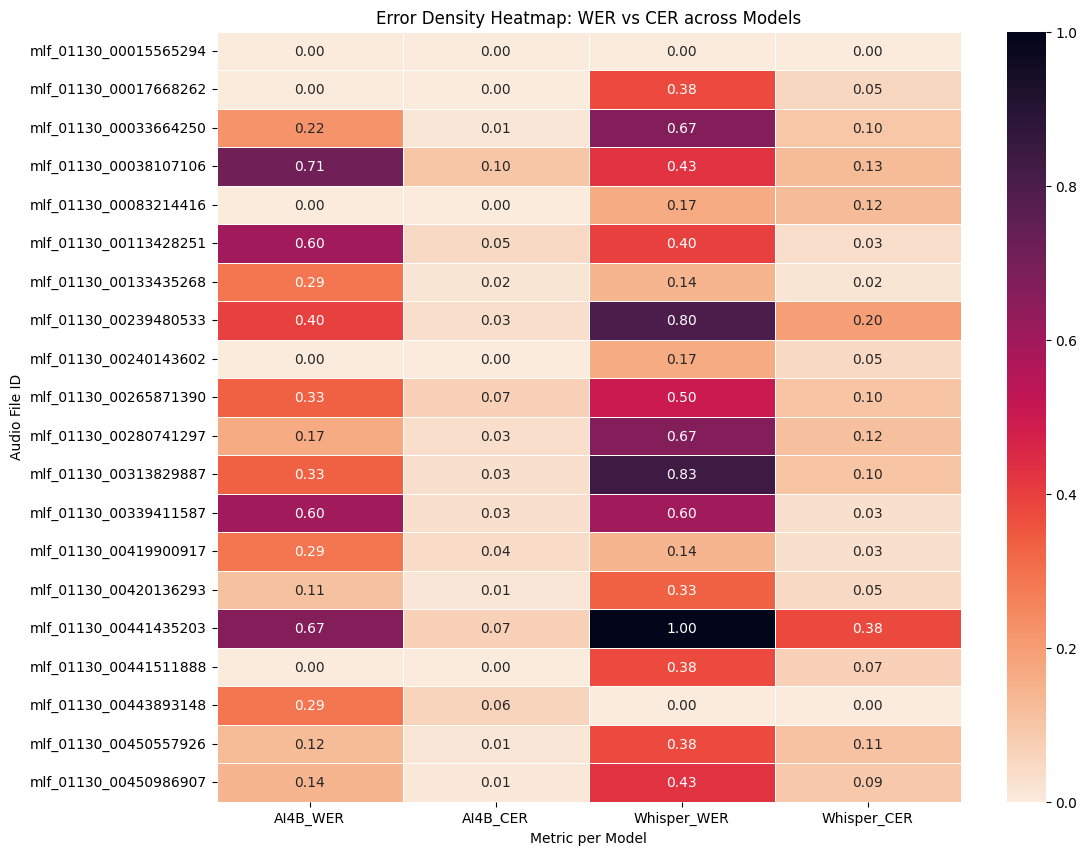

Total Audio Analysed: 2113 files
Total Duration: 182 minutes and 5 seconds


Top 10 Characters 'Lost' (Deleted) by AI4Bharat:


,Character,Deletion_Count
3,്,204
18,‍,188
0,,162
12,‌,137
16,.,131
4,ന,65
5,ു,51
22,e,47
23,t,38
10,ി,35



Top 10 Characters 'Lost' (Deleted) by Whisper:


,Character,Deletion_Count
2,്,318
3,,233
21,‌,133
30,.,132
4,ാ,127
8,ി,127
6,യ,104
5,ക,83
7,ു,71
11,ത,61


### Visualizing Character Loss
This chart compares the top 10 most frequently 'lost' (deleted) characters for both models.

Comparison data not found. Please run the evaluation loop first.


### Fixing Malayalam Font Rendering in Matplotlib
Colab's default environment lacks Malayalam fonts, causing 'square boxes' in plots. Run the following cell to install a compatible font and refresh the cache.

Selecting previously unselected package fonts-lohit-mlym.
(Reading database ... 122492 files and directories currently installed.)
Preparing to unpack .../fonts-lohit-mlym_2.92.2-2_all.deb ...
Unpacking fonts-lohit-mlym (2.92.2-2) ...
Setting up fonts-lohit-mlym (2.92.2-2) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
Font installed! Please RE-RUN the visualization cells below to see the Malayalam characters correctly.


### 3. Unicode Normalization Impact
Comparing raw WER against normalized WER (handling Chillu letters and ZWJ/ZWNJ) to ensure a fair linguistic comparison.

Calculating Normalized Metrics...
AI4Bharat Original Avg WER: 0.2452
AI4Bharat Normalized WER: 0.2829
--- 
Whisper Original Avg WER: 0.4000
Whisper Normalized WER: 0.4350

Normalization complete. These scores represent the models' true linguistic performance.


### Visualizing Normalized WER
This plot compares the baseline WER against the Normalized WER to show the impact of Malayalam-specific Unicode handling.

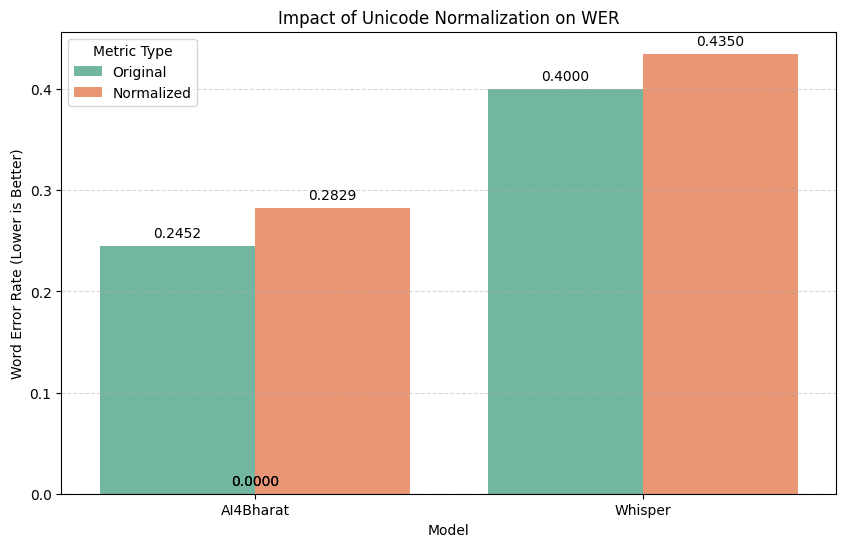

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib as mpl
import numpy as np # Added numpy for later use

print("Matplotlib and data handling libraries imported.")

Matplotlib and data handling libraries imported.


In [ ]:
import matplotlib.font_manager as fm

# Create FontProperties objects for explicit use
# `font_path` is set in cell 1535e4db

# Explicitly use the font file path for Malayalam font properties
malayalam_font_prop = fm.FontProperties(fname=font_path)

# For English text, we can use a standard sans-serif font like DejaVu Sans
english_font_prop = fm.FontProperties(family='DejaVu Sans')

print("FontProperties for Malayalam and English created.")

FontProperties for Malayalam and English created.


In [ ]:
# Install necessary font packages for Malayalam support
!apt-get update
!apt-get install -y fonts-indic fonts-noto-cjk fonts-noto-extra
!fc-cache -fv

print("Font packages installed and font cache rebuilt.")

# Re-apply the font configuration after installation
import matplotlib as mpl

# Set the generic font family to sans-serif
mpl.rcParams['font.family'] = 'sans-serif'

# Prioritize robust sans-serif fonts for general text (including English) globally.
# Noto Sans Malayalam will *not* be in this global list to prevent it from being tried for English characters.
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Liberation Sans']

print("Matplotlib font configuration updated.")

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-indic is already the newest version (2:1.4).
fonts-noto-cjk is already the newest versio

In [ ]:
import matplotlib.font_manager as fm
import os
import matplotlib as mpl # Import mpl here for direct use

# Find the path to Noto Sans Malayalam font
font_path = None
for root, dirs, files in os.walk('/usr/share/fonts/'):
    for file in files:
        if 'NotoSansMalayalam' in file and (file.endswith('.ttf') or file.endswith('.otf')):
            font_path = os.path.join(root, file)
            break
    if font_path:
        break

if font_path:
    print(f"Found Noto Sans Malayalam font at: {font_path}")
    # Removed fm.fontManager.addfont(font_path) to prevent implicit global usage.
    # The font will be used explicitly via fname in FontProperties where needed.
    print("Noto Sans Malayalam font path identified.")
else:
    print("Noto Sans Malayalam font not found. Please ensure it's installed.")

# Rebuild font cache just in case (though addfont should handle it for specific font)
fm._load_fontmanager()
print("Matplotlib font cache reloaded.")

Found Noto Sans Malayalam font at: /usr/share/fonts/truetype/noto/NotoSansMalayalam-CondensedExtraBold.ttf
Noto Sans Malayalam font path identified.
Matplotlib font cache reloaded.


## Conclusion & Summary
Based on the WER, CER, and normalized metrics above, we can determine the strengths of the AI4Bharat Conformer and Whisper Small architectures for Malayalam ASR tasks.